# DiaPredict: Patient Clustering and Cluster-Label Classification

This notebook discovers patient groups with K-Means, interprets those groups, and trains classifiers to reproduce the resulting cluster labels.

Follow the numbered sections in order. The supplied dataset has no confirmed diabetes outcome, so the final labels describe clusters rather than diagnoses.


## 0. Configure the Notebook Environment

Shared constants and paths come from `src/config.py`; CSV loading is handled by `src/data.py`. The Docker environment already sets `PYTHONPATH=/workspace`, so imports work from the notebook directory. Importing configuration does not create folders or read data.

Use `RANDOM_STATE` for later randomized operations. Save derived data to `PROCESSED_DATA_DIR`, leaving the raw CSV unchanged. No model is trained here.


In [1]:
import joblib
import pandas as pd
import numpy as np
from IPython import display
from IPython.core.pylabtools import figsize
from mlflow.metrics import precision_score
from mlflow.optuna.storage import mlflow_optuna_status_map
from numpy.ma.extras import average
from sklearn.semi_supervised.tests.test_self_training import y_test
from sklearn.utils.tests.test_pprint import PCA

from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

from src.config import RAW_DATA_PATH, RANDOM_STATE, PROCESSED_DATA_DIR
from src.data import load_data, outliers_for_all_columns, splitData, invalid_values_to_na, outliering


## 1. Define the Project Objective

Describe the dataset and the two learning stages: K-Means creates cluster labels, then classifiers learn those labels. There is no confirmed diabetes outcome in the supplied CSV; classification scores measure cluster agreement, not diagnostic accuracy.


### Workflow Overview

1. Inspect and validate the raw measurements.
2. Reserve a held-out test set.
3. Explore and preprocess the development data.
4. Compare clustering configurations and select a clustering model.
5. Interpret the discovered clusters and assign descriptive labels.
6. Compare classifiers, tune the selected model, and evaluate how well it reproduces the cluster labels on unseen data.

## 2. Load and Validate the Raw Dataset

Task 03: Load the CSV, inspect its shape and types, verify and remove the exported index, and check missing values and duplicates. Keep the raw file unchanged.


In [2]:
from src.data import clean_data
from IPython.display import display

df = load_data(RAW_DATA_PATH)
display(df.head())
display(df.describe())
display(df.isna().sum())
print(df.info())
print("cleaned data")
cleaned_df = clean_data(df)




,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0,6,148,72,35,0,33.6,0.627,50
1,1,1,85,66,29,0,26.6,0.351,31
2,2,8,183,64,0,0,23.3,0.672,32
3,3,1,89,66,23,94,28.1,0.167,21
4,4,0,137,40,35,168,43.1,2.288,33


,Unnamed: 0,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,383.500000,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885
std,221.846794,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000
25%,191.750000,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000
50%,383.500000,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000
75%,575.250000,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000
max,767.000000,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000


Unnamed: 0                  0
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                768 non-null    int64  
 1   Pregnancies               768 non-null    int64  
 2   Glucose                   768 non-null    int64  
 3   BloodPressure             768 non-null    int64  
 4   SkinThickness             768 non-null    int64  
 5   Insulin                   768 non-null    int64  
 6   BMI                       768 non-null    float64
 7   DiabetesPedigreeFunction  768 non-null    float64
 8   Age                       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
cleaned data


## 3. Reserve the Final Test Set

Task 04: Reserve the test patients before fitting preprocessing or clustering. Use `random_state=RANDOM_STATE` and save the split manifest in `PROCESSED_DATA_DIR`.


In [3]:
from src.data import splitData
from src.config import (
RANDOM_STATE,
PROCESSED_DATA_DIR
)

X_train, X_test = splitData(cleaned_df,0.2, RANDOM_STATE )
print(X_train.head(), X_test.head())
X_train.to_csv(PROCESSED_DATA_DIR / "trainset.csv", index = False)
X_test.to_csv(PROCESSED_DATA_DIR / "testset.csv", index = False)




     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
60           2.0     84.0            NaN            NaN      NaN   NaN   
618          9.0    112.0           82.0           24.0      NaN  28.2   
346          1.0    139.0           46.0           19.0     83.0  28.7   
294          0.0    161.0           50.0            NaN      NaN  21.9   
231          6.0    134.0           80.0           37.0    370.0  46.2   

     DiabetesPedigreeFunction   Age  
60                      0.304  21.0  
618                     1.282  50.0  
346                     0.654  22.0  
294                     0.254  65.0  
231                     0.238  46.0        Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
668          6.0     98.0           58.0           33.0    190.0  34.0   
324          2.0    112.0           75.0           32.0      NaN  35.7   
624          2.0    108.0           64.0            NaN      NaN  30.8   
690          8.0    107.0      

## 4. Explore the Development Data

Tasks 05–07: Explore development-data missingness, zero values, distributions, outliers, correlations, and feature variability. Save figures in `FIGURES_DIR` and summary tables in `TABLES_DIR`. Explain what each plot shows.


In [4]:

print("missing values")
print(cleaned_df.isna().sum())

print("=====================================shape")
print("rows",cleaned_df.shape[0])
print("=====================================duplicated")
print(cleaned_df.duplicated().sum())
print("=====================================zero values")
zero_values = cleaned_df.loc[(cleaned_df==0).any(axis=1)]
print(len(zero_values))



missing values
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64
=====================================shape
rows 768
=====================================duplicated
0
=====================================zero values
111


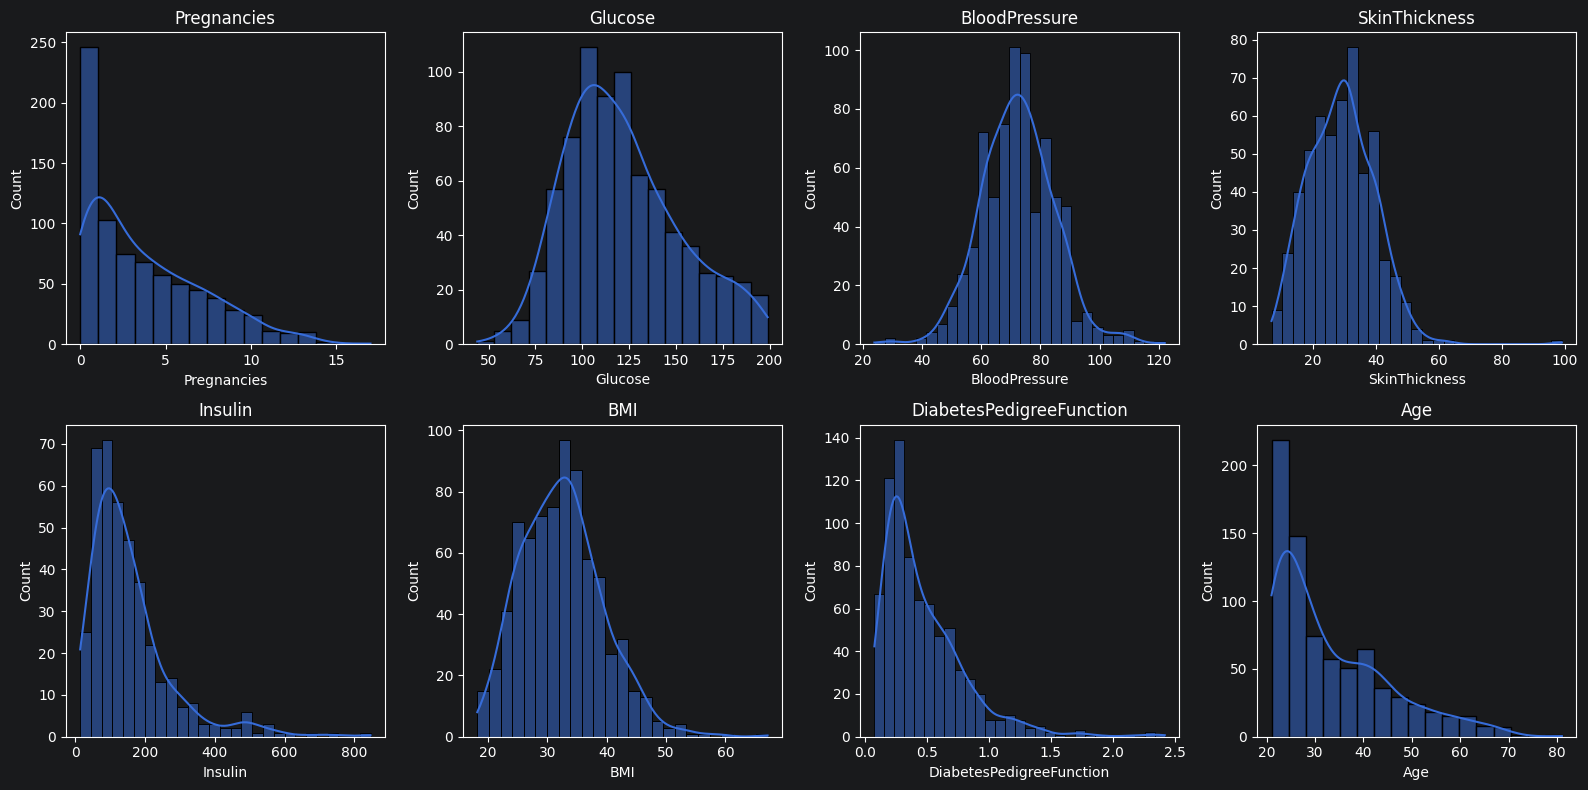

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, cleaned_df.columns):
    sns.histplot(cleaned_df[col], ax=ax, kde=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 4.1 Interpret the Feature Distributions

The histograms show where each feature is concentrated and whether its distribution is symmetric or skewed. Several measurements are right-skewed, so preprocessing and outlier decisions should be based on the training data rather than on a normal-distribution assumption.

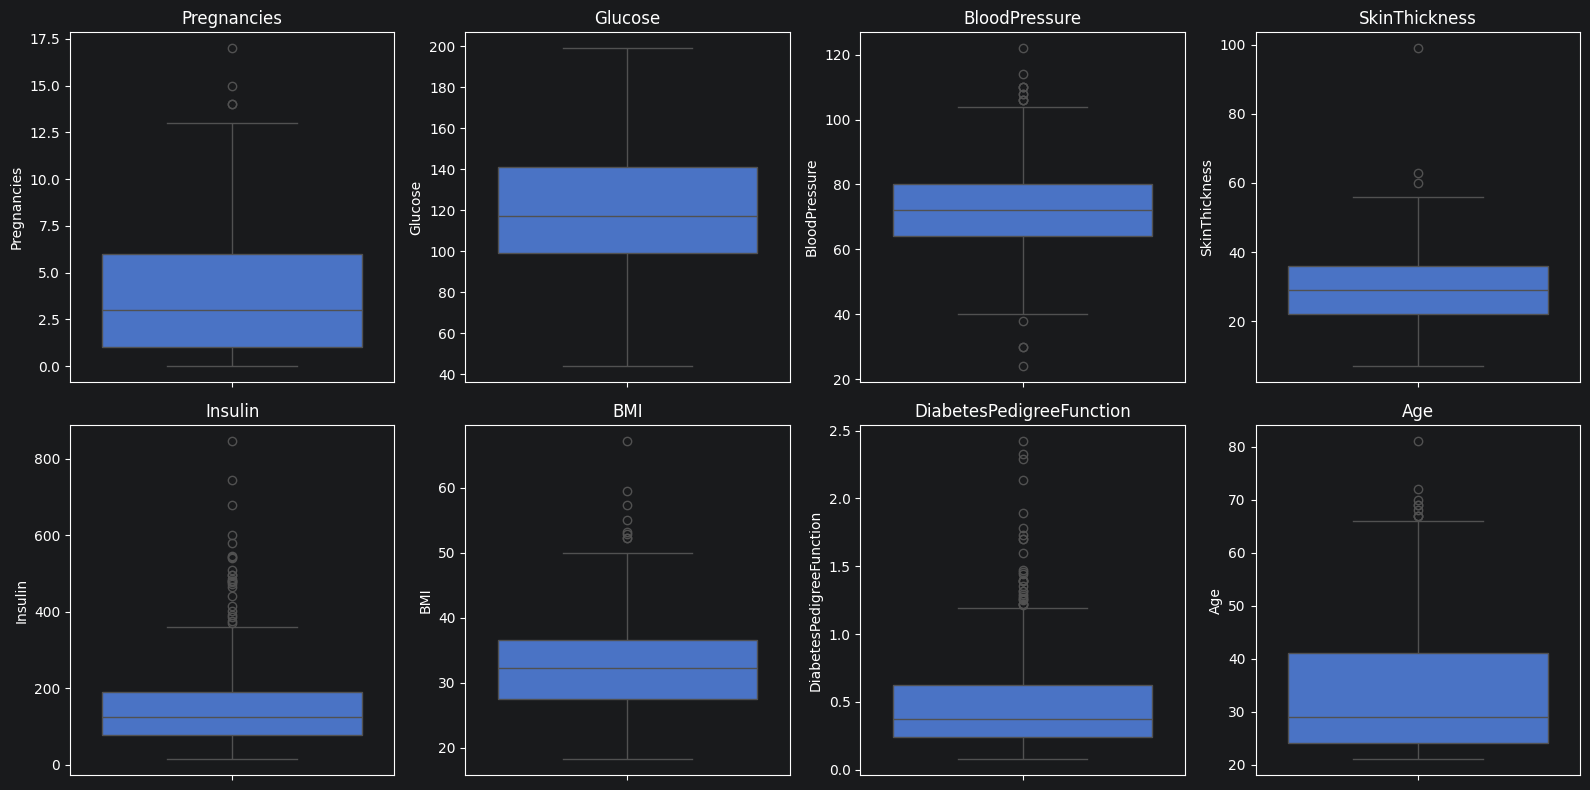

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flat, cleaned_df.columns):
    sns.boxplot(cleaned_df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 4.2 Review Boxplots and Count IQR-Flagged Values

The boxplots highlight values outside each feature's interquartile range. These values are candidates for investigation, not automatic errors; medically plausible extremes should be retained. The next cell counts the rows flagged by the IQR rule.

In [7]:
outliers = outliers_for_all_columns(cleaned_df)
rows_with_outliers = cleaned_df.loc[outliers.any(axis=1)]
display(cleaned_df.loc[outliers.any(axis=1)])
print("=========================numer of outliers is ===========================")
for col in outliers.columns:
    print(col, outliers[col].sum())
    #sum of tru false dw

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0
8,2.0,197.0,70.0,45.0,543.0,30.5,0.158,53.0
12,10.0,139.0,80.0,NaN,NaN,27.1,1.441,57.0
13,1.0,189.0,60.0,23.0,846.0,30.1,0.398,59.0
18,1.0,103.0,30.0,38.0,83.0,43.3,0.183,33.0
...,...,...,...,...,...,...,...,...
691,13.0,158.0,114.0,NaN,NaN,42.3,0.257,44.0
695,7.0,142.0,90.0,24.0,480.0,30.4,0.128,43.0
710,3.0,158.0,64.0,13.0,387.0,31.2,0.295,24.0
715,7.0,187.0,50.0,33.0,392.0,33.9,0.826,34.0


=========================numer of outliers is ===========================
Pregnancies 4
Glucose 0
BloodPressure 14
SkinThickness 3
Insulin 24
BMI 8
DiabetesPedigreeFunction 29
Age 9


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Pregnancies,1.000000,0.128135,0.214178,0.100239,0.082171,0.021719,-0.033523,0.544341
Glucose,0.128135,1.000000,0.223192,0.228043,0.581186,0.232771,0.137246,0.267136
BloodPressure,0.214178,0.223192,1.000000,0.226839,0.098272,0.289230,-0.002805,0.330107
SkinThickness,0.100239,0.228043,0.226839,1.000000,0.184888,0.648214,0.115016,0.166816
Insulin,0.082171,0.581186,0.098272,0.184888,1.000000,0.228050,0.130395,0.220261
BMI,0.021719,0.232771,0.289230,0.648214,0.228050,1.000000,0.155382,0.025841
DiabetesPedigreeFunction,-0.033523,0.137246,-0.002805,0.115016,0.130395,0.155382,1.000000,0.033561
Age,0.544341,0.267136,0.330107,0.166816,0.220261,0.025841,0.033561,1.000000


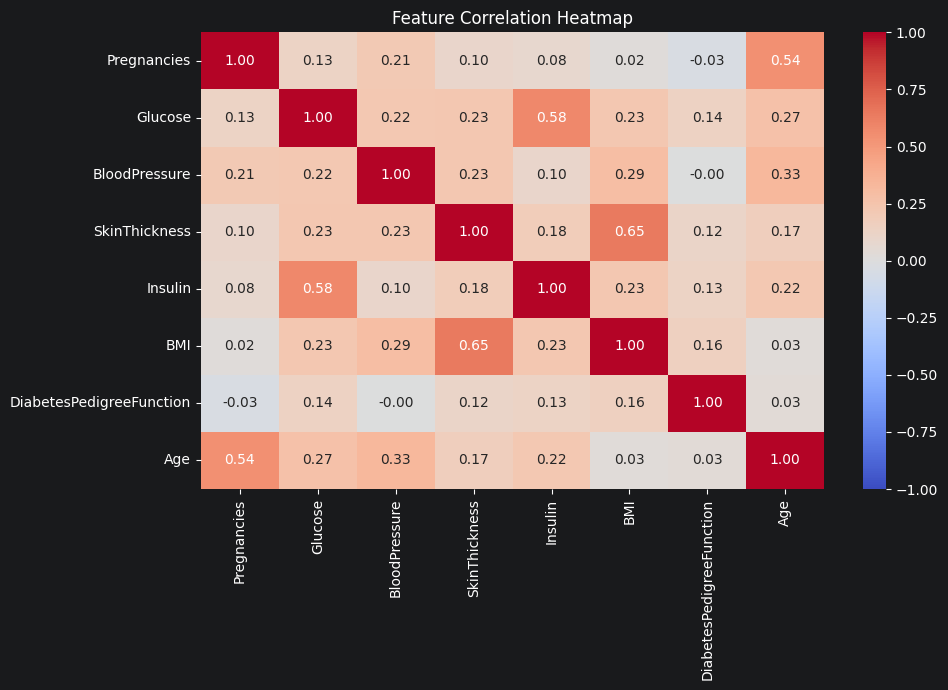

In [8]:
corr = cleaned_df.corr()
display(corr)
plt.figure(figsize=(10, 7))

sns.heatmap(
  corr,
  annot=True,
  cmap="coolwarm",
  vmin=-1,
  vmax=1,
  center=0,
  fmt=".2f",
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


## 5. Build and Apply Reusable Preprocessing

Task 08: Define the ordered feature list and reusable preprocessing: selected zero values to NaN, median imputation, any justified outlier treatment, and scaling. Fit learned transformations on training data only.


In [9]:
from src.data import invalid_values_to_na
validated_df = cleaned_df
print(validated_df.isna().sum())
print(( validated_df == 0).sum()) #NORMAL THING

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64
Pregnancies                 111
Glucose                       0
BloodPressure                 0
SkinThickness                 0
Insulin                       0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


### 5.1 Validate Measurements and Mark Missing Values

A value of zero is valid for `Pregnancies`. For `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI`, zero represents a missing or invalid measurement and is converted to `NaN` before imputation.

### 5.2 Inspect Feature-Specific Outliers

Review unusual values feature by feature before deciding whether they are invalid, plausible extremes, or values that need training-only treatment.


In [10]:
from src.data import outliering

for col in outliers.columns:
    print(col)
    display(validated_df.loc[outliers[col], [col]])





Pregnancies


,Pregnancies
88,15.0
159,17.0
298,14.0
455,14.0


Glucose


,Glucose


BloodPressure


...

,BMI
120,53.2
125,55.0
177,67.1
193,52.3
247,52.3
303,52.9
445,59.4
673,57.3


DiabetesPedigreeFunction


,DiabetesPedigreeFunction
4,2.288
12,1.441
39,1.390
45,1.893
58,1.781
100,1.222
147,1.400
187,1.321
218,1.224
228,2.329


Age


,Age
123,69.0
363,67.0
453,72.0
459,81.0
489,67.0
537,67.0
666,70.0
674,68.0
684,69.0


#### Feature-by-Feature Interpretation of Unusual Values

An IQR outlier is unusual compared with the other patients in this development split. It is not automatically an error and should not be deleted without evidence.

- **Pregnancies** — practical range **0–20 pregnancies**: zero is valid; negative or non-integer values are invalid.
- **Glucose** — practical range **1–600 mg/dL**: zero is treated as missing here; high values can be real observations and are not automatically errors. Negative values are invalid.
- **BloodPressure** — practical range **1–200 mmHg**: this is diastolic pressure; zero is treated as missing. Values outside this broad measurement range should be checked for data-entry errors.
- **SkinThickness** — practical range **1–100 mm**: zero is treated as missing; negative values are impossible. High values can still be valid body measurements.
- **Insulin** — practical range **1–1,000 microU/mL**: zero is treated as missing. The feature is right-skewed, so high values may be plausible; negative values are invalid.
- **BMI** — practical range **10–80 kg/m²**: zero is treated as missing. For adult screening, 18.5–24.9 is commonly called healthy weight, 25–29.9 overweight, and 30 or higher obesity; these categories do not define valid data limits.
- **DiabetesPedigreeFunction** — practical range **0–3**: this is a non-negative family-history score, not a probability. Values above 1 are allowed; negative values are invalid.
- **Age** — practical range **21–100 years**: this dataset contains adults. Zero, negative, or non-integer ages are invalid.

These are broad project data-quality ranges, not universal clinical normal ranges. The feature names, units, and dataset population are documented in the OpenML/UCI metadata (https://www.openml.org/api/v1/json/data/37). Retain plausible IQR extremes, convert only verified invalid measurements (including sentinel zeros) to missing, and use median or KNN imputation inside the training pipeline. If clipping is justified later, learn bounds from training data only.

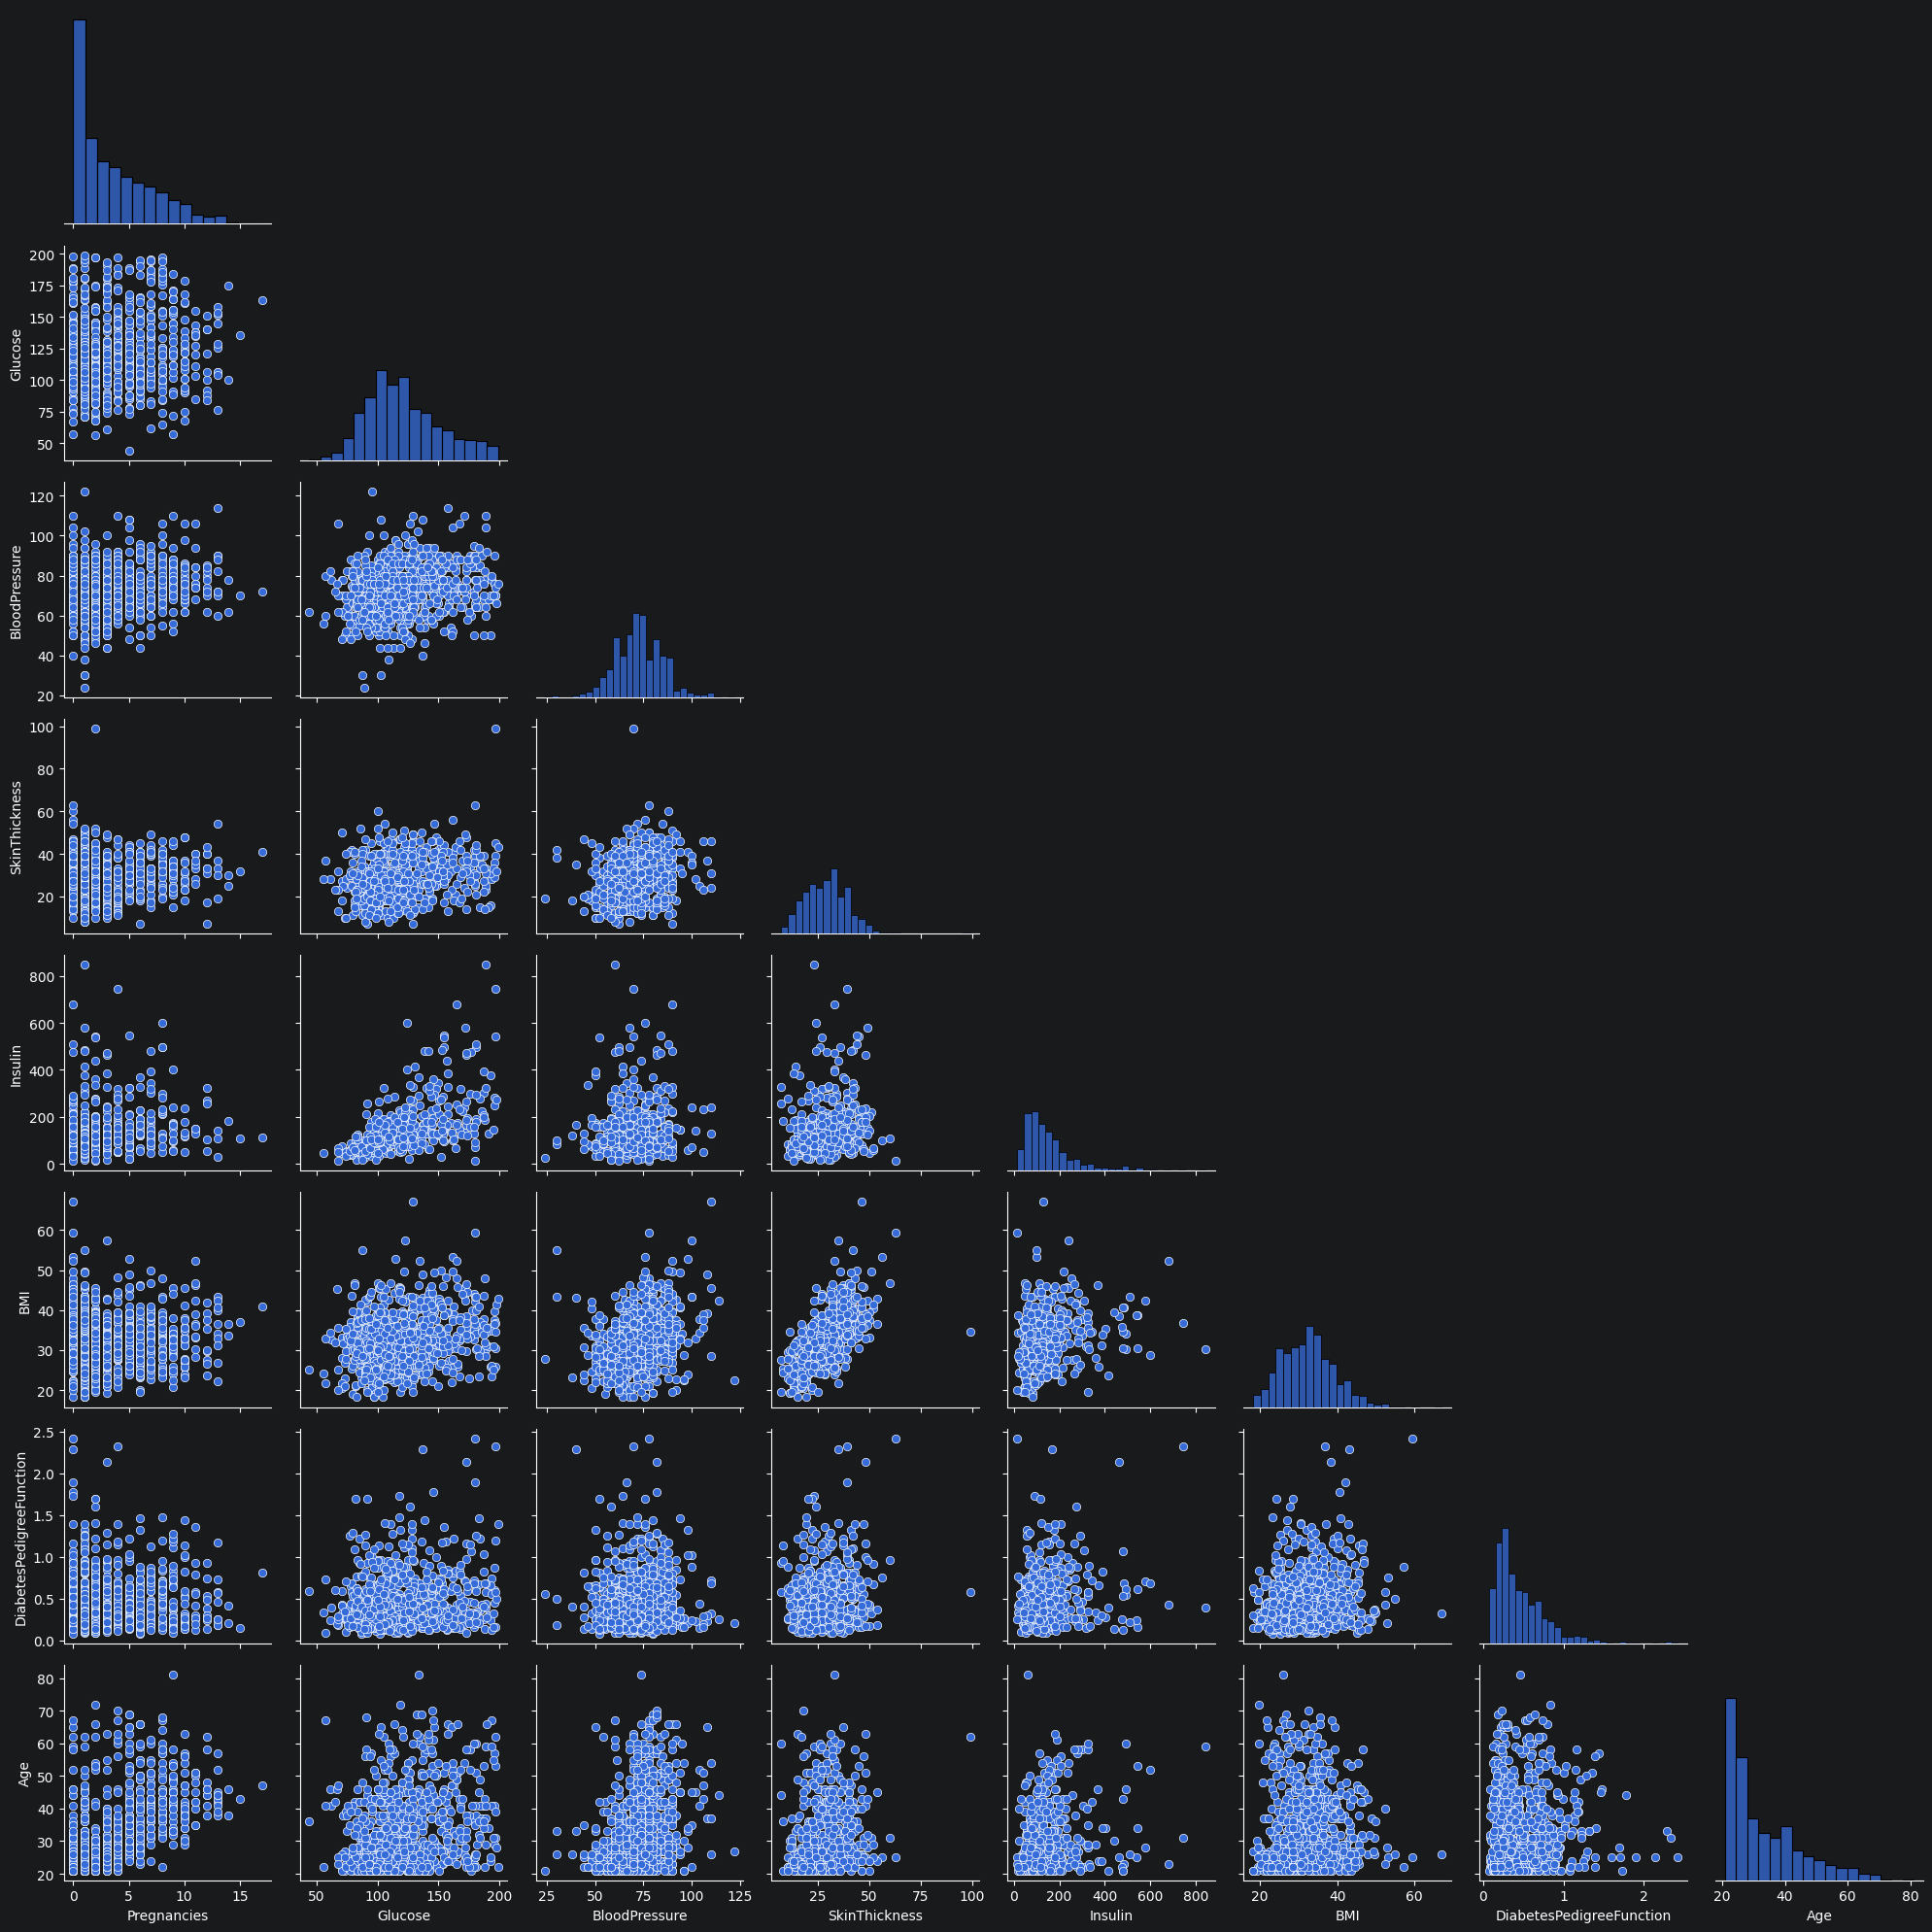

In [11]:
#pairplot


sns.pairplot(validated_df, diag_kind="hist", corner= True)
plt.tight_layout()
plt.show()


### 5.3 Fit, Apply, and Save the Preprocessing Pipeline

Fit the reusable preprocessing pipeline on the training split, transform both splits with the fitted pipeline, then save it for later inference.

In [12]:
from src.preprocessing import build_preprocessor


X_train , X_test = splitData(validated_df,0.2,1)
preprocessor = build_preprocessor("knn")
processed_x_train = preprocessor.fit_transform(X_train)
processed_x_test = preprocessor.fit_transform(X_test)

processed_x_train = pd.DataFrame(
  processed_x_train,
  columns= preprocessor.get_feature_names_out() ,
  index=X_train.index,
)
processed_x_test = pd.DataFrame(
    processed_x_test,
    columns= preprocessor.get_feature_names_out(),
    index=X_test.index,
)

outliers = outliers_for_all_columns(processed_x_train)

for col in outliers.columns:
  print(col)
  display(processed_x_train.loc[outliers[col], [col]])


BMI


,BMI
177,2.738066
673,2.738066


Insulin


,Insulin


Pregnancies


...

,BloodPressure


SkinThickness


,SkinThickness


Glucose


,Glucose


In [13]:
#create the preprocessor


joblib.dump(preprocessor, "../models/preprocessor.joblib")

['../models/preprocessor.joblib']

## 6. Configure MLflow Experiment Tracking

Set the tracking server and experiment before logging clustering and classification runs.

In [14]:
import os
import mlflow

mlflow.set_tracking_uri(os.getenv("MLFLOW_MODEL_URI"))

## 7. Select the Number of K-Means Clusters

### 7.1 Evaluate Candidate Values of k

Compare inertia, silhouette score, and cluster sizes for each candidate value of `k`, and log every configuration as a separate MLflow run.

In [15]:
from sklearn.cluster import KMeans, kmeans_plusplus
from sklearn.metrics import silhouette_score, accuracy_score, recall_score, f1_score
import mlflow
result = []

mlflow.set_experiment("clustering")
for k in range(2, 20):
    with mlflow.start_run(run_name=f"kmeans-selection-{k}"):
        kmeans = KMeans(
            n_clusters=k,
            n_init=20,
            random_state= RANDOM_STATE
        )
        #log mlflow parameters
        mlflow.log_params({"n_clusters": k , "n_init": 20, "random_state": RANDOM_STATE})
        labels = kmeans.fit_predict(processed_x_train)
        metric = {
            "k": k,
            "inertia": kmeans.inertia_,
            "silhouette_score": silhouette_score(processed_x_train, labels),
            "smallest_cluster_sizes": pd.Series(labels).value_counts().min(),
            "biggest_cluster_sizes": pd.Series(labels).value_counts().min()
        }
        mlflow.log_metrics(metric)
        result.append(metric)

kmeans_results = pd.DataFrame(result)
print(kmeans_results)


2026/10/06 23:33:56 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet



🏃 View run kmeans-selection-2 at: http://mlflow:5000/#/experiments/2/runs/f8f746b03d1e4b5cb626cd2be5c9c303
🧪 View experiment at: http://mlflow:5000/#/experiments/2
🏃 View run kmeans-selection-3 at: http://mlflow:5000/#/experiments/2/runs/a2bb16420b4d4376b4d269ef1cec5eb1
🧪 View experiment at: http://mlflow:5000/#/experiments/2
🏃 View run kmeans-selection-4 at: http://mlflow:5000/#/experiments/2/runs/0e79c1106edb49c78ffeb8060d240274
🧪 View experiment at: http://mlflow:5000/#/experiments/2
🏃 View run kmeans-selection-5 at: http://mlflow:5000/#/experiments/2/runs/b9fa462524274a19b0073fc3c84b61fa
🧪 View experiment at: http://mlflow:5000/#/experiments/2
🏃 View run kmeans-selection-6 at: http://mlflow:5000/#/experiments/2/runs/5f8fb97c031f45758e4d2eb4005c83b7
🧪 View experiment at: http://mlflow:5000/#/experiments/2
🏃 View run kmeans-selection-7 at: http://mlflow:5000/#/experiments/2/runs/91e91f9bec064ab98180104fecf86f35
🧪 View experiment at: http://mlflow:5000/#/experiments/2
🏃 View run kmean

### 7.2 Plot the Elbow Curve and Silhouette Scores

Use inertia to locate the elbow and silhouette score to assess cluster separation. Consider both metrics together rather than selecting `k` from only one plot.

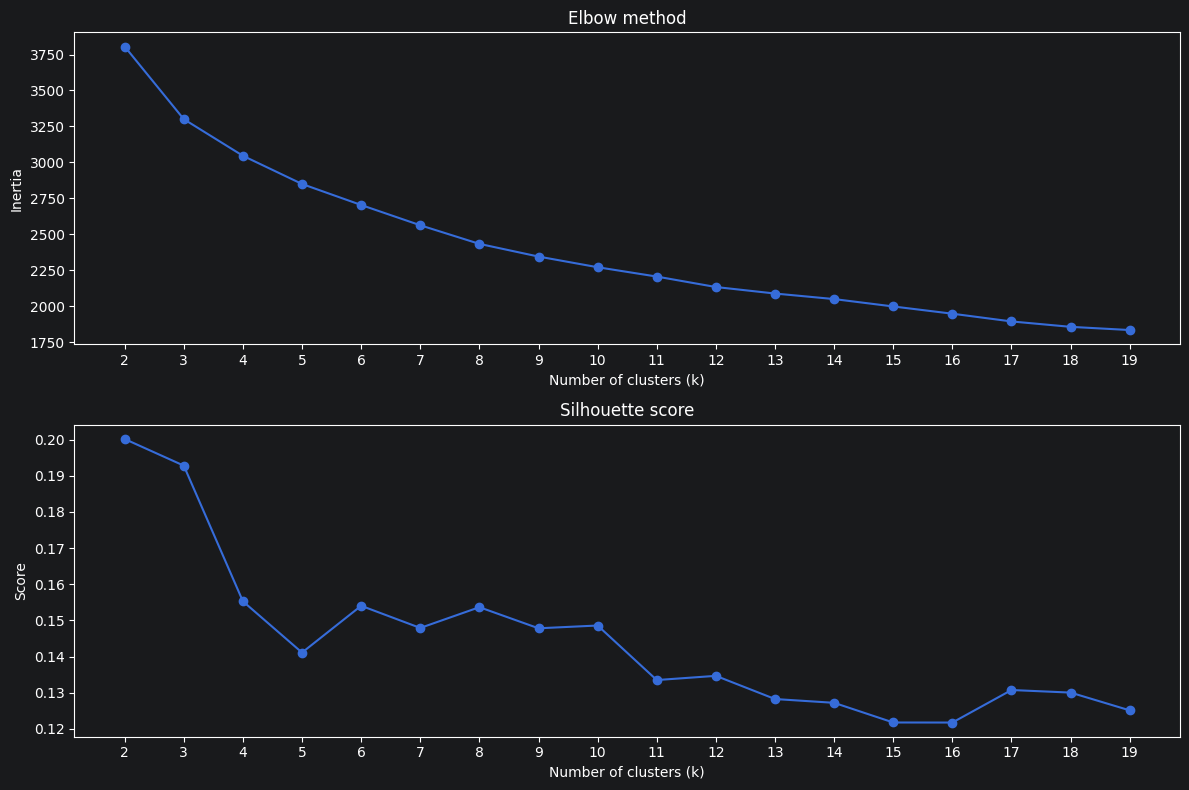

🏃 View run kmeans-selection-summary at: http://mlflow:5000/#/experiments/2/runs/175ef1991af04972b319a37db779dc54
🧪 View experiment at: http://mlflow:5000/#/experiments/2


In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(kmeans_results["k"], kmeans_results["inertia"], marker="o")
axes[0].set(title="Elbow method", xlabel="Number of clusters (k)",
ylabel="Inertia", xticks=kmeans_results["k"])
axes[1].plot(kmeans_results["k"], kmeans_results["silhouette_score"],
marker="o")
axes[1].set(title="Silhouette score", xlabel="Number of clusters (k)",
ylabel="Score", xticks=kmeans_results["k"])

plt.tight_layout()
plt.show()

with mlflow.start_run(run_name="kmeans-selection-summary"):
    mlflow.log_figure(fig, "figures/kmeans_selection.png")
    mlflow.log_table(kmeans_results, "tables/kmeans_selection.json")

### 7.3 Record the K-Means Selection Decision

The reduction in inertia becomes smaller after `k=3`, while the silhouette scores for `k=2` and `k=3` remain similar. Therefore, `k=3` is selected as a reasonable balance between compact clusters and a more informative patient segmentation.

## 8. Compare K-Means with DBSCAN

### 8.1 Visualize the Selected K-Means Solution

Project the processed features into two principal components to inspect the selected three-cluster solution visually. The following cells then search DBSCAN configurations and visualize its best candidate.

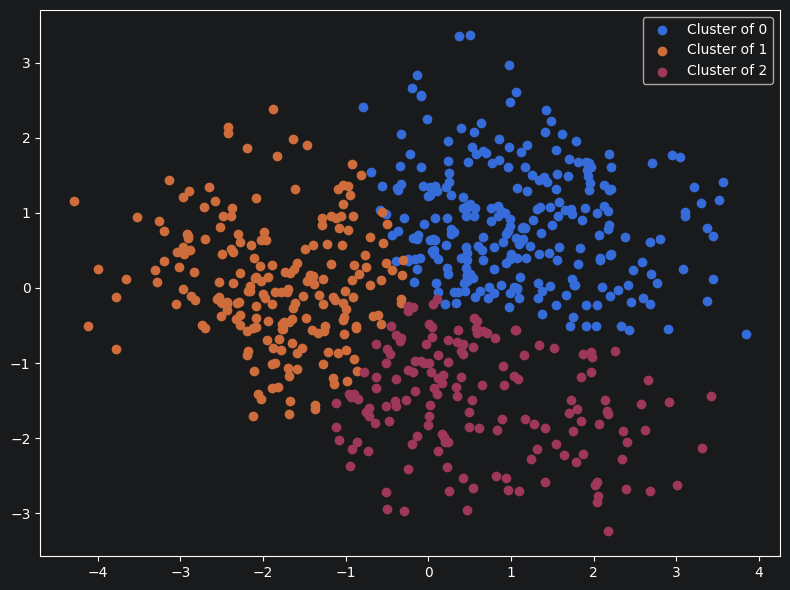

🏃 View run kmeans-clusters-visualisation at: http://mlflow:5000/#/experiments/2/runs/db29abc4d3bc4c3a87aa852677e0e85a
🧪 View experiment at: http://mlflow:5000/#/experiments/2


In [37]:
#kmeans visulisation :
labels = KMeans(n_clusters=3, random_state=RANDOM_STATE ).fit_predict(processed_x_train)
points = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(processed_x_train)
kmeans_plot_df = pd.DataFrame(points, columns=["PC1", "PC2"])
kmeans_plot_df["cluster"] = labels


fig, axes = plt.subplots(1,1, figsize=(8,6))
for cluster, group in kmeans_plot_df.groupby("cluster"):
    plt.scatter(
        group["PC1"],
        group["PC2"],
        label = f"Cluster of {cluster}"
    )
plt.tight_layout()
plt.legend()
plt.show()

with mlflow.start_run(run_name="kmeans-clusters-visualisation"):
    mlflow.log_figure(fig, "figures/kmeans_clusters_spreading.png")


In [18]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from IPython.display import display
result = []

epss = np.arange(1.0, 4.1, 0.2)
min_samples = [3,5, 7, 9]
for eps in epss:

    for min_sample in min_samples:
        with mlflow.start_run(run_name=f"dbscan-epsilon({eps}-min({min_sample})"):
            labels = DBSCAN(eps=eps, min_samples=min_sample).fit_predict(processed_x_train)
            non_noise = labels != -1
            n_clusters = len(set(labels[non_noise]))
            nois_fraction = (labels == -1).mean()

            if n_clusters >= 2:
                score = silhouette_score(
                    processed_x_train[non_noise],
                    labels[non_noise]
                )
            else:
                score = None
            metrics = {
                "eps": eps,
                "min_samples": min_sample,
                "clusters": n_clusters,
                "noise_fraction": nois_fraction,
            }
            if score is not None:
                metrics["silhouette_score"] = score

            mlflow.log_metrics(metrics)
            mlflow.log_params({"epsilon": eps, "min_sample": min_sample})
            result.append({
                "eps": eps,
                "min_samples": min_sample,
                "clusters": n_clusters,
                "noise_fraction": nois_fraction,
                "silhouette_score": score
            })

dbscan_results = pd.DataFrame(result)
display(dbscan_results.sort_values("silhouette_score", ascending=False))


🏃 View run dbscan-epsilon(1.0-min(3) at: http://mlflow:5000/#/experiments/2/runs/d442beabb39c4aaa97f115d57ce8f7c9
🧪 View experiment at: http://mlflow:5000/#/experiments/2
🏃 View run dbscan-epsilon(1.0-min(5) at: http://mlflow:5000/#/experiments/2/runs/d5471fa636bb4e30a3b6368bdbe0d871
🧪 View experiment at: http://mlflow:5000/#/experiments/2
🏃 View run dbscan-epsilon(1.0-min(7) at: http://mlflow:5000/#/experiments/2/runs/6833b31ef7494715947cd82ee8575e61
🧪 View experiment at: http://mlflow:5000/#/experiments/2
🏃 View run dbscan-epsilon(1.0-min(9) at: http://mlflow:5000/#/experiments/2/runs/e8b758c31ebd4aa6b5b4f1e9ae2eb151
🧪 View experiment at: http://mlflow:5000/#/experiments/2
🏃 View run dbscan-epsilon(1.2-min(3) at: http://mlflow:5000/#/experiments/2/runs/1736fc52d53f4891861e9677d6c5e8fd
🧪 View experiment at: http://mlflow:5000/#/experiments/2
🏃 View run dbscan-epsilon(1.2-min(5) at: http://mlflow:5000/#/experiments/2/runs/b388286686fc413eb7f5f432e5cd935b
🧪 View experiment at: http://ml

,eps,min_samples,clusters,noise_fraction,silhouette_score
7,1.2,9,2,0.921824,0.376039
12,1.6,3,2,0.144951,0.290996
1,1.0,5,5,0.941368,0.281639
0,1.0,3,19,0.828990,0.277454
6,1.2,7,4,0.837134,0.148439
...,...,...,...,...,...
59,3.8,9,1,0.000000,NaN
60,4.0,3,1,0.000000,NaN
61,4.0,5,1,0.000000,NaN
62,4.0,7,1,0.000000,NaN


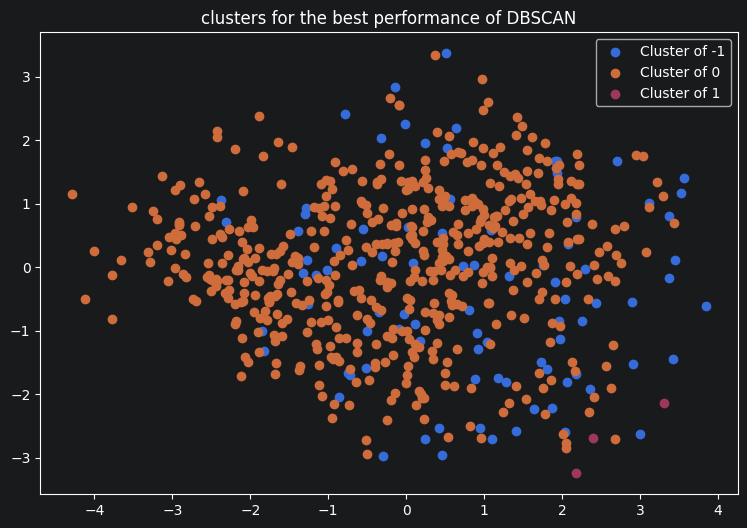

In [29]:
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Replace with your selected parameters
eps = 1.6
min_samples = 3

labels = DBSCAN(
  eps=eps,
  min_samples=min_samples
).fit_predict(processed_x_train)

points_2d = PCA(n_components=2,
random_state=RANDOM_STATE).fit_transform(
  processed_x_train
)

plt.figure(figsize=(9, 6))
plt.title("clusters for the best performance of DBSCAN")
dbscan_plot_df = pd.DataFrame(points_2d, columns=["PC1", "PC2"])
dbscan_plot_df["cluster"] = labels
for cluster, group in dbscan_plot_df.groupby("cluster"):
    plt.scatter(
        group["PC1"],
        group["PC2"],
        label= f"Cluster of {cluster}"
    )
plt.legend()
plt.show()

### 8.2 Choose the Final Clustering Algorithm

For this experiment, K-Means is selected because it produces a stable, complete three-cluster partition with clearer separation in the PCA projection than the evaluated DBSCAN configurations. This is an experimental comparison, not proof that the boundaries are clinically meaningful.

## 9. Fit, Profile, and Save the Final K-Means Model

In [44]:
from src.clustering_pipeline import Kmean_build_clustering_pipeline
from IPython.display import display
#analyse the clusters :
with mlflow.start_run(run_name="kmean-chosen-k=3"):
    kmean_pp = Kmean_build_clustering_pipeline(n_clusters=3)
    model = kmean_pp.fit(processed_x_train)
    labels  = kmean_pp.predict(processed_x_train)
    test_labels = kmean_pp.predict(processed_x_test)

    mlflow.sklearn.log_model(model, "ideal_kmean")
    mlflow.log_params({
        "k": 3,
        "random_state": RANDOM_STATE,

    })

    cluster_sizes = pd.Series(labels).value_counts()
    print(cluster_sizes)

    mlflow.log_metrics({
        "silhouette_score": silhouette_score(processed_x_train, labels),
        "smallest_cluster_size": cluster_sizes.min(),
        "largest_cluster_size": cluster_sizes.max()
    })

    processed_x_train["target"] = labels
    processed_x_test["target"] = test_labels
    cluster_profiles = processed_x_train.groupby("target").agg(
        patient_count = ("Age", "size"),
        pregnancies_mean = ("Pregnancies", "mean"),
        Glucose_mean = ("Glucose", "mean"),
        BloodPressure_mean = ("BloodPressure", "mean"),
        SkinThickness_mean = ("SkinThickness", "mean"),
        Insulin_mean = ("Insulin", "mean"),
        BMI_mean = ("BMI", "mean"),
        DiabetesPedigreeFunction_mean = ("DiabetesPedigreeFunction", "mean"),
        Age_mean=("Age", "mean")
    )

    cluster_profiles["percentage"] = (cluster_profiles["patient_count"]/ len(processed_x_train))
    display(cluster_profiles)


    clusters = processed_x_train.groupby("target").mean()
    mlflow.log_artifact("../reports/tables/cluster_profile_kmean.csv", cluster_profiles)



    avg = processed_x_train.mean()
    display(clusters)
    display(clusters-avg)

2026/10/07 00:06:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/07 00:06:12 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


0    248
1    204
2    162
Name: count, dtype: int64


,patient_count,pregnancies_mean,Glucose_mean,BloodPressure_mean,SkinThickness_mean,Insulin_mean,BMI_mean,DiabetesPedigreeFunction_mean,Age_mean,percentage
target,,,,,,,,,,
0,248,0.813216,0.327219,0.447198,0.170965,0.372211,0.096708,-0.036154,0.938132,0.403909
1,204,-0.387962,-0.717629,-0.500604,-0.812064,-0.845537,-0.737429,-0.219361,-0.721192,0.332248
2,162,-0.756379,0.402753,-0.054209,0.760875,0.494946,0.780567,0.331580,-0.527986,0.263844


🏃 View run kmean-chosen-k=3 at: http://mlflow:5000/#/experiments/2/runs/12efe599581c453d97f8af8075ceb049
🧪 View experiment at: http://mlflow:5000/#/experiments/2


ValueError: The truth value of a DataFrame is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [ ]:
#we should save our model now



import joblib
joblib.dump(model, "../models/kmeans_clustering.joblib")




## 10. Interpret and Name the Clusters


### 10.1 Apply the Assignment's Risk-Interpretation Rule

A cluster whose mean glucose is above 126, mean BMI is above 30, and mean Diabetes Pedigree Function is above 0.5 may be described as a higher-risk profile for this project. This interpretation describes group averages and is not an individual diagnosis.

### 10.2 Describe the Cluster Profiles and Map Their Labels

- Cluster 0 – Older and higher-pregnancy profile: This group has the highest average age and number of pregnancies. Its glucose, insulin, and blood-pressure values are moderately above the overall average, while BMI remains close to average.
- Cluster 1 – Lower-measurement profile: This group has below-average values for all main features, including glucose, insulin, BMI, age, blood pressure, and skin thickness. It represents the least elevated health-measurement profile.
- Cluster 2 – Higher BMI and glucose profile: This group is younger and has fewer pregnancies on average, but it shows higher BMI, skin thickness, glucose, insulin, and Diabetes Pedigree Function values.

In [ ]:
labeling = {
    0: "old-pregnant",
    1: "low-measurement",
    2: "high-bmi-glucose"
}


y_train = processed_x_train.pop("target").map(labeling)
x_test = processed_x_test.pop("target").map(labeling)


## 11. Compare Baseline Classifiers

Evaluate the configured multiclass classifiers with cross-validation on the training data and compare their mean validation metrics.

In [ ]:
from src.classification import *

# print(y_train)

metrics = cross_validate_pipelines(processed_x_train, y_train)
display(pd.DataFrame(metrics).T)


### 11.1 Select a Classifier for Tuning

Logistic regression is selected for tuning because it provides the strongest overall cross-validation metrics among the evaluated baseline models.

## 12. Tune and Evaluate the Selected Classifier

Run grid search with multiclass scoring, inspect the cross-validation results, save the best estimator, and evaluate it once on the held-out test set.

In [ ]:
from src.tuning import tune_model

grid_search = tune_model("logistic_regression", processed_x_train, y_train)
best_model_index = grid_search.best_index_
results = grid_search.cv_results_



display(pd.DataFrame([
    results["mean_test_accuracy"][best_model_index],
    results["mean_test_precision"][best_model_index],
    results["mean_test_recall"][best_model_index],
    results["mean_test_f1"][best_model_index],
], index=["accuracy", "precision", "reacll", "f1"]).T)

In [ ]:
joblib.dump(grid_search.best_estimator_, "../models/regression_logistique_tuned.joblib")

In [ ]:
model = joblib.load("../models/regression_logistique_tuned.joblib")
ypredicted = model.predict(processed_x_test)

from sklearn.metrics import (
accuracy_score, precision_score, recall_score, f1_score
)

test_metrics = {
    "accuracy": accuracy_score(x_test, ypredicted),
    "precision": precision_score(x_test, ypredicted, average="macro", zero_division=0),
    "recall": recall_score(x_test, ypredicted, average="macro", zero_division=0),
    "f1_macro": f1_score(x_test, ypredicted, average="macro", zero_division=0)
}

display(pd.DataFrame([test_metrics]))
